**Questions for EDA:**
* Are there any NaN values or duplicated rows?
* What are the distributions for each feature/target?
* Are there any outliers? If so, can they be explained?
* Are any features correlated?
* Are there any correlations between NaNs in different columns?
* What additional features could carry predictive power?

*Are there any NaN values or duplicated rows?*

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

# import data
df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/train.csv')
df.isna().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [2]:
df.duplicated().any()

np.False_

There are NaNs in all columns apart from the target and ID columns. There are no duplicate entries.

*What are the distributions for each feature/target?*

In [3]:
df.describe()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


<Axes: xlabel='condition'>

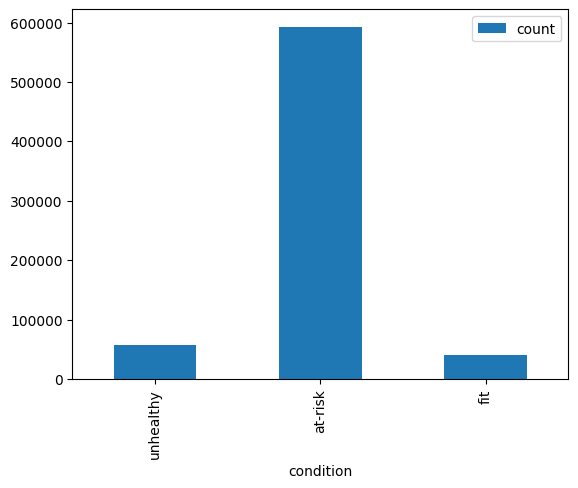

In [4]:
distdf = pd.DataFrame({
    'condition': df['health_condition'].unique(), 
    'count': [df[df['health_condition']==cat]['id'].count() for cat in df['health_condition'].unique()]
})
distdf.plot.bar(x='condition', y='count')

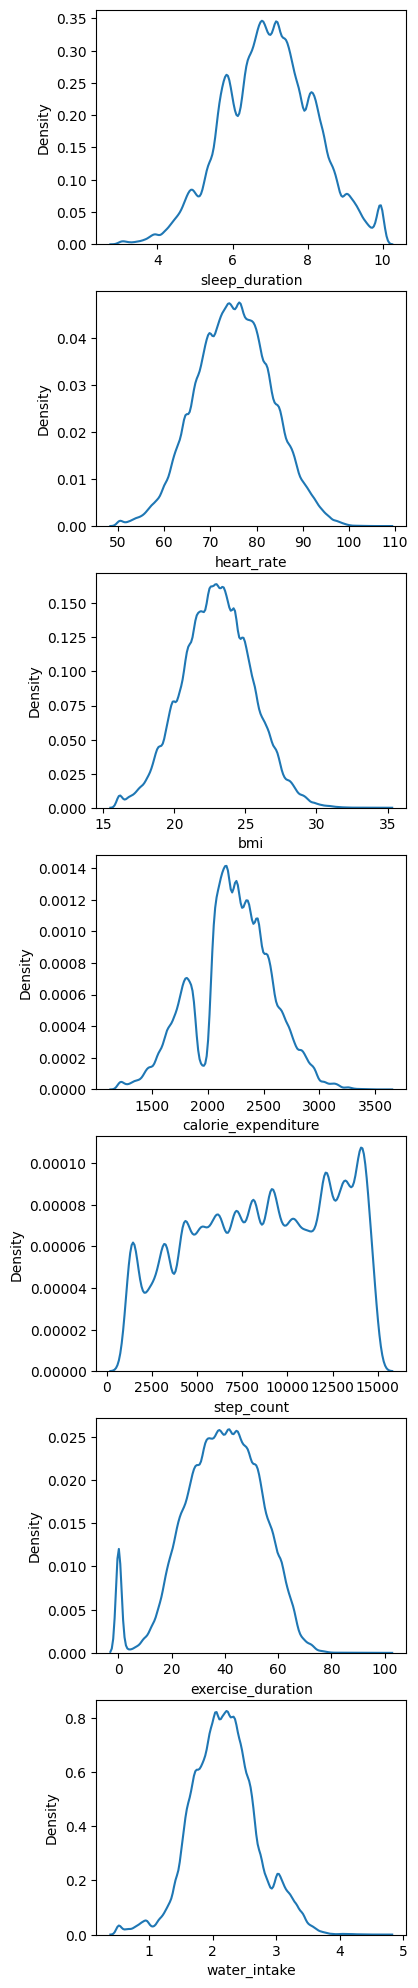

In [5]:
cont = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
fig, ax = plt.subplots(nrows=7, figsize=(4, 25))

for i in range(7):
    sns.kdeplot(x=df[cont[i]], ax=ax[i])
plt.show()

In [6]:
df['exercise_duration'][df['exercise_duration']==0].count()

np.int64(16491)

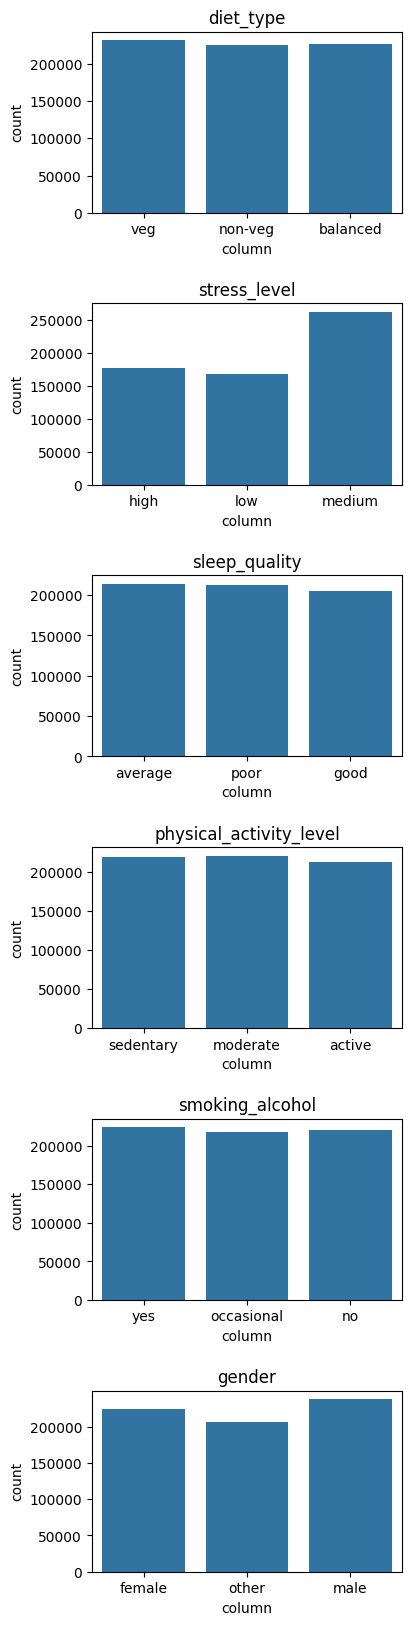

In [7]:
cols = ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']
fig, ax = plt.subplots(nrows=6, figsize=(4, 20))

for i, column in enumerate(cols):
    distdf = pd.DataFrame({'column': df[column].unique(), 'count': [df[df[column]==cat]['id'].count() for cat in df[column].unique()]})
    sns.barplot(distdf, x='column', y='count', ax = ax[i])
    ax[i].set_title(column)
    
plt.subplots_adjust(hspace=0.5)
plt.show()

There is a class imbalance of target labels. Evaluation metrics and models should be chosen carefully - the balanced accuracy metric and balanced class weights in models are suitable.

Stress level is also slightly imbalanced, so could carry predictive power.


*Are there any outliers? If so, can they be explained?*

Exercise duration has a spike at zero. The distribution seems to be normal otherwise, so it could be caused by having a lower limit of zero rather than -inf.


*Are any features correlated?*


<Axes: >

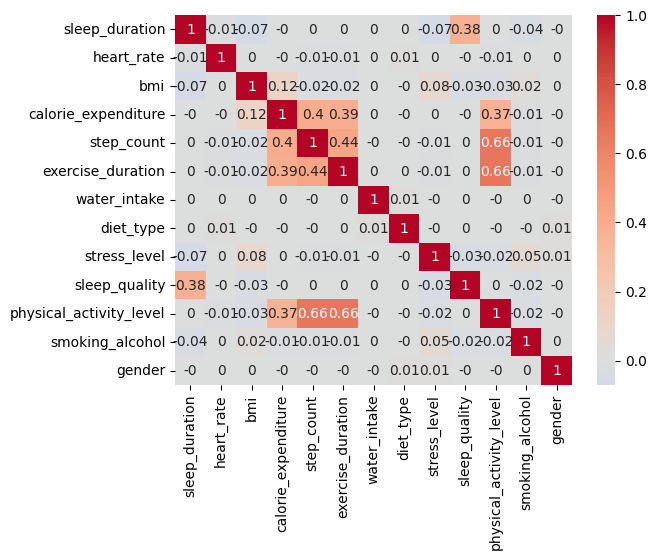

In [8]:
# encode the categorical features
encoded_df = df.copy()
encoded_df['gender'] = encoded_df['gender'].map({'male': 0, 'other': 1, 'female': 2})
encoded_df['smoking_alcohol'] = encoded_df['smoking_alcohol'].map({'no': 0, 'occasional': 1, 'yes': 2})
encoded_df['physical_activity_level'] = encoded_df['physical_activity_level'].map({'sedentary': 0, 'moderate': 1, 'active': 2})
encoded_df['sleep_quality'] = encoded_df['sleep_quality'].map({'poor': 0, 'average': 1, 'good': 2})
encoded_df['stress_level'] = encoded_df['stress_level'].map({'low': 0, 'medium': 1, 'high': 2})
encoded_df['diet_type'] = encoded_df['diet_type'].map({'non-veg': 0, 'balanced': 1, 'veg': 2})

# drop non-features and show heatmap
encoded_df = encoded_df.drop(['id', 'health_condition'], axis=1)
sns.heatmap(encoded_df.corr().round(2), annot=True, cmap="coolwarm", center=0)

Four features are pairwise correlated with each other: physical_activity_level, calorie_expenditure, step_count, and exercise_duration. Two more are correlated: sleep_quality and sleep_duration.

If using Logistic Regression, an L2 penalty should be applied to manage multicollinearity.

*Are there any correlations between NaNs in different columns?*

<Axes: >

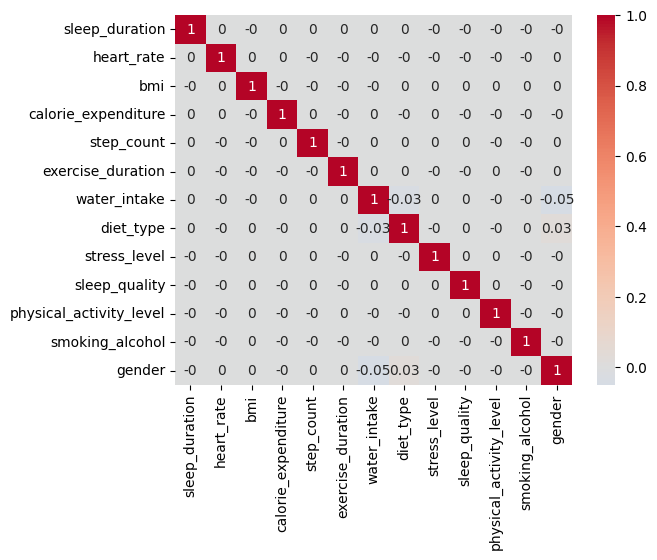

In [9]:
missing = df.drop(['id', 'health_condition'], axis=1).isna()
sns.heatmap(missing.corr().round(2), annot=True, cmap="coolwarm", center=0)

There is no meaningful correlation between the NaNs in different columns.

*What additional features could carry predictive power?*

Two ideas:
* Number of NaN in each row
* exercise_duration x physical_activity_level

Both of these are used in the pipeline.